# Toy Model: Filtering

In [12]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
import pandas as pd

# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
plt.rcParams['savefig.dpi'] = 400 
# enable math fonts
mpl.rc('mathtext', default = 'regular')

period_limit = 200. # days
dist_limit = 500.  # pc (nb:2000. == 200AU/0.1arcsec)
radius_limit = 8.   # Re
max_radius_error = 0.25 # fraction

output_file = "filtered_data.pkl"

## Read in the data

### Data from Sullivan (db)

In [13]:
# read in Kendall's catalog, xmatched to all the stuff from Kepler that I need
with open('tables/kendall+kepler.pkl', 'rb') as file:
       tmp = pickle.load(file)
db = tmp[ tmp['koi_disposition']!='FALSE POSITIVE' ]

print('Binaries, all planets', len(db))
print('Binaries, unique stars', len(db['KOI'].unique()))

Binaries, all planets 401
Binaries, unique stars 291


### KOI+Gaia data

In [14]:
# read in my kois table
with open('tables/kois+gaia.pkl', 'rb') as file:
        kois = pd.read_pickle(file)

### Data from Thebault & Bonani (tb)

In [15]:
# confirmed planets only
allbin = Table.read('tables/plan_allbinall.mrt', format='ascii.mrt').to_pandas()

mask = allbin['Alternate'].str.match(r'^KOI\d+(?:\.\d+)?$', na=False)
tmp = allbin.loc[mask].copy()
tmp['KOI'] = tmp['Alternate'].str.extract(r'KOI0*(\d+)', expand=False).astype(int)
tb=tmp.merge(kois, on='KOI', suffixes=['','_y'])

print('Binaries, all planets', len(tb))
print('Binaries, unique stars', len(tb['KOI'].unique()))

tb

Binaries, all planets 429
Binaries, unique stars 265


,Most,Alternate,Mass,Mass_1,Distance,Method,semi-major,eccentricicy,Number,semi-major_1,...,koi_kepmag,koi_steff,teff,source_id,parallax,parallax_over_error,kepler_gaia_ang_dist,phot_g_mean_mag,ruwe,bedell_cat
0,Kepler693,KOI824,0.760,0.15,1002.0,1,2.9,0.48,1,0.1120,...,16.422,4986.0,4986.0,2.103573e+18,0.860426,23.373724,0.144240,16.402374,0.990593,good
1,Kepler420,KOI1257,0.990,0.70,900.0,1,5.3,0.31,1,0.3820,...,14.651,5522.0,5522.0,2.126633e+18,0.438738,2.051622,0.107118,14.671575,13.121313,good
2,Kepler968,KOI1833,0.760,0.39,312.0,1,5.3,99.00,3,0.0634,...,14.265,4402.0,4402.0,2.132152e+18,3.453282,246.269897,0.189787,14.238413,1.027291,good
3,Kepler968,KOI1833,0.760,0.39,312.0,1,5.3,99.00,3,0.0634,...,14.265,4402.0,4402.0,2.132152e+18,3.453282,246.269897,0.189787,14.238413,1.027291,good
4,Kepler968,KOI1833,0.760,0.39,312.0,1,5.3,99.00,3,0.0634,...,14.265,4402.0,4402.0,2.132152e+18,3.453282,246.269897,0.189787,14.238413,1.027291,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,Kepler52,KOI775,0.624,0.50,321.5,1,9842.0,99.00,3,0.1820,...,15.095,4126.0,4126.0,2.133590e+18,3.128331,163.341995,0.062209,15.040696,1.028861,good
425,Kepler52,KOI775,0.624,0.50,321.5,1,9842.0,99.00,3,0.1820,...,15.095,4126.0,4126.0,2.133590e+18,3.128331,163.341995,0.062209,15.040696,1.028861,good
426,Kepler614,KOI587,0.850,0.50,571.0,1,9861.0,99.00,1,0.1050,...,14.574,5258.0,5258.0,2.085520e+18,1.870353,117.367470,0.050430,14.532136,0.967129,good
427,Kepler1143,KOI2210,0.810,0.50,632.0,1,10517.0,99.00,2,0.6220,...,15.195,4895.0,4895.0,2.100405e+18,1.769829,91.814102,0.073748,15.180281,0.985003,good


In [16]:
tmp = tb[['KOI']].drop_duplicates().reset_index(drop=True)

# merge T&B and Sullivan
tmp = tmp.merge(db[['KOI','SepAU']].drop_duplicates().reset_index(drop=True), on='KOI', how='left')

# only 5 of the close-separation binaries in T&B are not from Sullivan+23,24
check = tmp.loc[~np.isfinite(tmp['SepAU']),'KOI']

tmp

,KOI,SepAU
0,824,NaN
1,1257,NaN
2,1833,5.791592
3,3138,5.565432
4,2005,13.017874
...,...,...
260,886,NaN
261,1165,NaN
262,775,NaN
263,587,NaN


## Merge Sullivan and T&B, Calc snowline

In [17]:
db_sub = db[['KOI','kepoi_name','Teff1', 'Teff2', 
             'distance', 'SepAU', 'ruwe',
             'koi_disposition', 'koi_period', 'koi_prad', 'Rppri']].copy()
db_sub['steff_adopt'] = db['Teff1']
db_sub['prad_adopt'] = db['Rppri']
db_sub['e_prad_adopt'] = db['e_Rppri']

lum = (db['Teff1'].astype(float)/5777.)**4 * db['Rstar1']**2
db_sub['mass_pri_adopt'] = lum**0.25
lum = (db['Teff2'].astype(float)/5777.)**4 * (db['Rstar2_Rstar1']*db['Rstar1'])**2
db_sub['mass_sec_adopt'] = lum**0.25

tb_sub = tb[['KOI','kepoi_name', 'Mass', 'Mass_1',
             'ruwe',
            'koi_disposition', 'koi_period', 'koi_prad']].copy()
tb_sub['steff_adopt'] = tb['teff']
tb_sub['prad_adopt'] = tb['koi_prad']
tb_sub['e_prad_adopt'] = np.max([tb['koi_prad_err1'], np.abs(tb['koi_prad_err2'])], axis=0)
tb_sub['mass_pri_adopt'] = tb['Mass']
tb_sub['mass_sec_adopt'] = tb['Mass_1']
tb_sub['distance'] = 1000./tb['parallax']
tb_sub['SepAU'] = tb['semi-major']


binaries = db_sub.merge(
    tb_sub,
    on=["KOI", "kepoi_name"],                
    how="outer",
    suffixes=("_A", "_B"))

overlap = [col for col in db_sub.columns if col in tb_sub.columns and col != "KOI" and col != "kepoi_name"] 
for col in overlap:
    # adopt values from sullivan
    binaries[col] = binaries[f"{col}_A"].combine_first(binaries[f"{col}_B"])
    # drop the two temporary columns
    binaries.drop(columns=[f"{col}_A", f"{col}_B"], inplace=True)

binaries = binaries.drop_duplicates(subset=['KOI', 'kepoi_name'])


q = binaries['mass_pri_adopt']/binaries['mass_sec_adopt']
RL = 0.49*q**(2/3)/(0.6*q**(2/3)+np.log(1+q**(1/3))) # verified against https://dev.adsabs.harvard.edu/scan/
disk = RL * binaries['SepAU']

binaries['DiskAU'] = disk
binaries['SnowAU'] = 0.00465*0.5*(binaries['steff_adopt']/170.)**2 # for T_eq = 170K




In [18]:
# Check period ratios for each KOI
failing_kois = []
for koi, group in binaries.groupby('KOI'):
    periods = sorted(group['koi_period'].values)
    if len(periods) > 1:
        ratios = [periods[i+1] / periods[i] for i in range(len(periods)-1)]
        if any(r <= 1.15 for r in ratios):
            failing_kois.append(koi)

print("KOIs with period ratios <= 1.15:", failing_kois)

KOIs with period ratios <= 1.15: [284, 1101]


## Single-star hosts: Basic filtering 

Not a known binary, not a false positive, has a parallax, has RUWE<1.2

### KOIs

In [19]:
kois_less = kois[ (~kois['kepoi_name'].isin(binaries['kepoi_name'])) & \
                 (kois['koi_disposition']!='FALSE POSITIVE') & \
                 np.isfinite(kois['parallax']) & \
                 (kois['ruwe']<1.2) ].copy()

# at least one CONFIRMED per KOI 
has_confirmed = (
    kois_less.groupby('KOI')['koi_disposition']
    .transform(lambda s: (s == 'CONFIRMED').any())
)

kois_less['has_confirmed'] = has_confirmed

print('KOIs, singles', len(kois_less))
print('KOIs, unique stars', len(kois_less['KOI'].unique()))

KOIs, singles 3861
KOIs, unique stars 2944


### CKS Sample

In [20]:
tmp = Table.read('tables/fulton2018.vot').to_pandas()
tmp['kepoi_name'] = tmp['KOI']
tmp['KOI'] = tmp['kepoi_name'].str.extract(r'K0*(\d+)\.\d+')[0].astype(int)
cks=tmp.merge(kois, on='kepoi_name', suffixes=['','_y'])


cks_less = cks[ (~cks['kepoi_name'].isin(binaries['kepoi_name'])) & \
                (cks['koi_disposition']!='FALSE POSITIVE') & \
                 np.isfinite(cks['parallax']) & \
                 (cks['ruwe']<1.2) &  (cks['koi_kepmag']<14.2) ]

print('CKS, all planets', len(cks_less))
print('CKS, unique stars', len(cks_less['KOI'].unique()))

CKS, all planets 962
CKS, unique stars 664


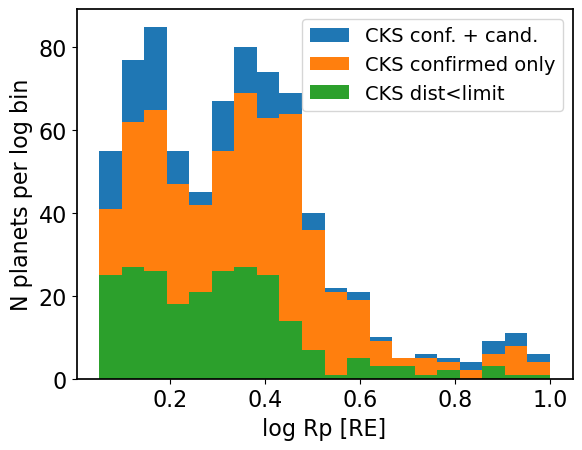

In [21]:
plt.hist(np.log10(cks_less['Rp']), range=(0.05,1), bins=20,
        label='CKS conf. + cand.')
plt.hist(np.log10(cks_less['Rp'][cks_less['koi_disposition']=='CONFIRMED']), 
         range=(0.05,1), bins=20,
         label='CKS confirmed only')
plt.hist(np.log10(cks_less['Rp'][1000./cks_less['parallax']<dist_limit]), range=(0.05,1), bins=20,
        label='CKS dist<limit')
plt.xlabel('log Rp [RE]')
plt.ylabel('N planets per log bin')
plt.legend()

## Define subsamples

### Define and apply filters

Limit on planet period and distance to star

In [22]:
# drop these, where the periods are too close
incorrect = (binaries['KOI'] == 284) | (binaries['KOI'] == 1101)
binaries = binaries[~incorrect]


# filter the sample
db_lim = ((binaries['koi_period'] < period_limit) & \
        (binaries['distance'] < dist_limit))

kois_lim = (kois_less['koi_period'] < period_limit)  & \
        (1000./kois_less['parallax'] < dist_limit)
cks_lim = (cks_less['Per'] < period_limit) & \
        (1000./cks_less['parallax'] < dist_limit)
       
# at least one SMALL per KOI 
has_small = (
    kois_less.groupby('KOI')['koi_prad']
    .transform(lambda s: (s < radius_limit).all())
)
kois_less['has_small'] = has_small

# at least one SMALL per KOI 
has_small = (
    binaries.groupby('KOI')['prad_adopt']
    .transform(lambda s: (s < radius_limit).all())
)
binaries['has_small'] = has_small

has_small = (
    cks_less.groupby('KOI')['Rp']
    .transform(lambda s: (s < radius_limit).all())
)
cks_less['has_small'] = has_small


# filter the binaries
binaries_filtered = binaries[(binaries['has_small']) & db_lim].copy()
rad_good = binaries_filtered['e_prad_adopt']/binaries_filtered['prad_adopt'] < max_radius_error
print(len(binaries_filtered))

# filter the KOIs
kois_filtered_cc = kois_less[(kois_less['has_small']) & kois_lim].copy()
print(len(kois_filtered_cc))
kois_cc_rad_good = np.max([kois_filtered_cc['koi_prad_err1'], np.abs(kois_filtered_cc['koi_prad_err2'])], axis=0)/kois_filtered_cc['koi_prad'] < max_radius_error

# Filter CKS
cks_filtered = cks_less[(cks_less['has_small']) & cks_lim].copy()
cks_filtered['n_planets'] = cks_filtered.groupby('KOI').KOI.transform('size')
cks_rad_good = (cks_filtered['koi_prad_err1'] - cks_filtered['koi_prad_err2'])/cks_filtered['Rp']/2. < max_radius_error


195
662


/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_79242/2956102917.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cks_less['has_small'] = has_small


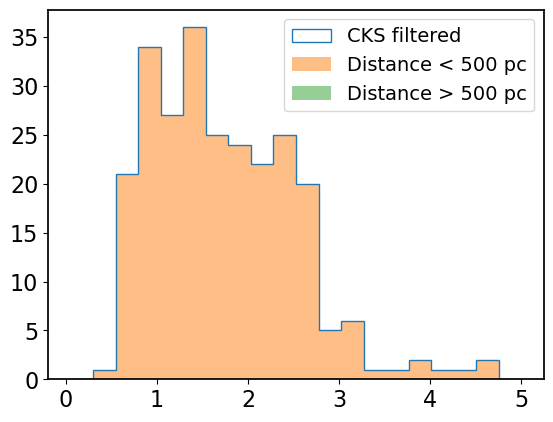

In [23]:
plt.hist(cks_filtered['Rp'][(cks_filtered['koi_disposition']=='CONFIRMED') & cks_rad_good], 
         range=(0.05,5), bins=20, density=False, histtype='step', label='CKS filtered')
plt.hist(cks_filtered['Rp'][(1000./cks_filtered['parallax'] < 500.) & (cks_filtered['koi_disposition']=='CONFIRMED') & cks_rad_good], 
         range=(0.05,5), bins=20, density=False, alpha=0.5, label='Distance < 500 pc')
plt.hist(cks_filtered['Rp'][(1000./cks_filtered['parallax'] > 500.) & (cks_filtered['koi_disposition']=='CONFIRMED') & cks_rad_good], 
         range=(0.05,5), bins=20, density=False, alpha=0.5, label='Distance > 500 pc')

plt.legend()

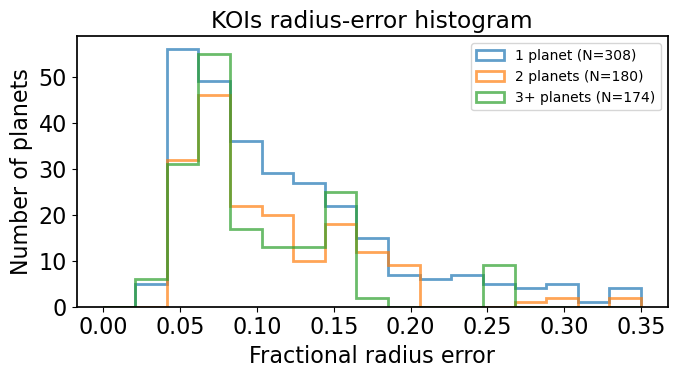

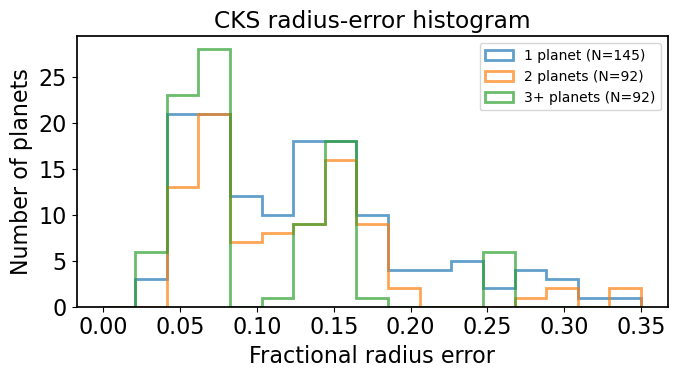

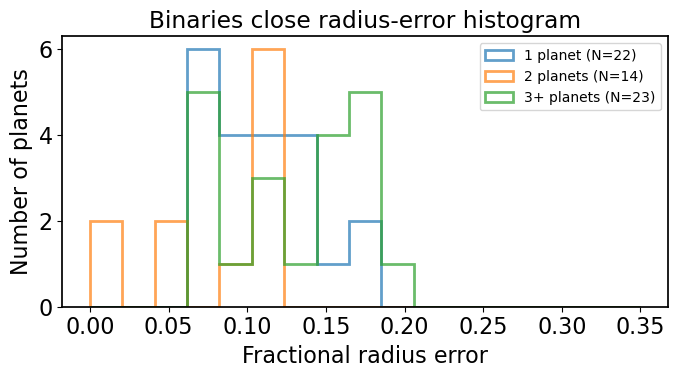


KOIs planets:
  radius_error < 0.25: total_planets=590
    n=1: systems=260, planets=260, frac_systems=0.667
    n=2: systems=84, planets=168, frac_systems=0.215
    n=3: systems=28, planets=84, frac_systems=0.072
    n=4: systems=12, planets=48, frac_systems=0.031
    n=5: systems=6, planets=30, frac_systems=0.015
  all radius errors: total_planets=662
    n=1: systems=308, planets=308, frac_systems=0.688
    n=2: systems=90, planets=180, frac_systems=0.201
    n=3: systems=32, planets=96, frac_systems=0.071
    n=4: systems=12, planets=48, frac_systems=0.027
    n=5: systems=6, planets=30, frac_systems=0.013

CKS planets:
  radius_error < 0.25: total_planets=297
    n=1: systems=127, planets=127, frac_systems=0.655
    n=2: systems=42, planets=84, frac_systems=0.216
    n=3: systems=16, planets=48, frac_systems=0.082
    n=4: systems=7, planets=28, frac_systems=0.036
    n=5: systems=2, planets=10, frac_systems=0.010
  all radius errors: total_planets=329
    n=1: systems=145, plane

In [24]:
# Histogram of radius error by system multiplicity for CKS
cks_filtered['radius_error'] = np.maximum(cks_filtered['koi_prad_err1'], np.abs(cks_filtered['koi_prad_err2'])) / cks_filtered['koi_prad']
kois_filtered_cc['radius_error'] = np.maximum(kois_filtered_cc['koi_prad_err1'], np.abs(kois_filtered_cc['koi_prad_err2'])) / kois_filtered_cc['koi_prad']

cks_filtered['n_planets'] = cks_filtered.groupby('KOI').KOI.transform('size')
kois_filtered_cc['n_planets'] = kois_filtered_cc.groupby('KOI').KOI.transform('size')

close = binaries_filtered['SepAU'] < 100.
binaries_filtered['radius_error'] = binaries_filtered['e_prad_adopt'] / binaries_filtered['prad_adopt']
binaries_filtered['n_planets'] = binaries_filtered.groupby('KOI').KOI.transform('size')

multiplicity_groups = [
    (lambda df: df['n_planets'] == 1, '1 planet'),
    (lambda df: df['n_planets'] == 2, '2 planets'),
    (lambda df: df['n_planets'] >= 3, '3+ planets'),
]

for df, label in [(kois_filtered_cc, 'KOIs'), (cks_filtered, 'CKS'), (binaries_filtered[close], 'Binaries close')]:
    plt.figure(figsize=(7, 4))
    bins = np.linspace(0, 0.35, 18)

    i = 0
    for func, grp_label in multiplicity_groups:
        grp_mask = func(df)
        sel = df[grp_mask]
        if len(sel) == 0:
            continue
        plt.hist(sel['radius_error'], bins=bins, ec=f'C{i}', 
                 histtype='step', lw=2, alpha=0.7, label=f'{grp_label} (N={len(sel)})')
        i+=1

    plt.xlabel('Fractional radius error')
    plt.ylabel('Number of planets')
    plt.title(f'{label} radius-error histogram')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    
def planet_fraction_by_multiplicity(df, star_col='KOI'):
    planet_counts = df.groupby(star_col).size().reset_index(name='n_planets')
    if len(df) == 0:
        return {}
    multiplicity_counts = planet_counts['n_planets'].value_counts().sort_index()
    total_systems = len(planet_counts)
    return {
        n: {
            'systems': count,
            'planets': int(n * count),
            'fraction_of_systems': float(count) / total_systems,
        }
        for n, count in multiplicity_counts.items()
    }

for df, label in [(kois_filtered_cc, 'KOIs'), (cks_filtered, 'CKS'), (binaries_filtered[close], 'Binaries close')]:
    sel = df
    print(f"\n{label} planets:")
    for error_label, mask in [
        ('radius_error < 0.25', sel['radius_error'] < 0.25),
        ('all radius errors', np.ones(len(sel), dtype=bool)),
    ]:
        subset = sel[mask]
        fractions = planet_fraction_by_multiplicity(subset)
        print(f"  {error_label}: total_planets={len(subset)}")
        if not fractions:
            print("    no planets in this selection")
            continue
        for n, stats in fractions.items():
            print(f"    n={n}: systems={stats['systems']}, planets={stats['planets']}, frac_systems={stats['fraction_of_systems']:.3f}")



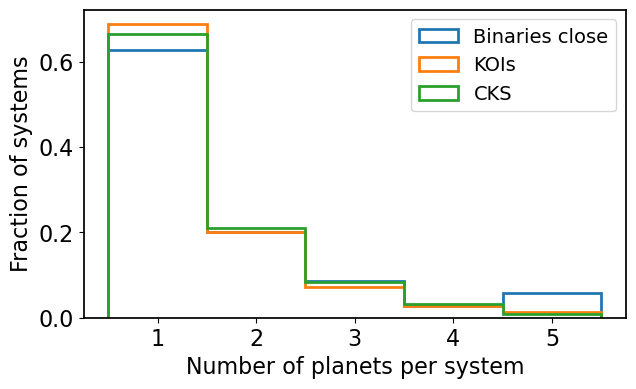

In [25]:
# Histogram of number of planets per system
plt.figure(figsize=(7,4))
bins = np.arange(0.5, 6.5, 1)
for df, label in [(binaries_filtered[close], 'Binaries close'), (kois_filtered_cc, 'KOIs'), (cks_filtered, 'CKS')]:
    systems = df.drop_duplicates('KOI')
    plt.hist(systems['n_planets'], bins=bins, histtype='step', lw=2, label=label, density=True)
plt.xlabel('Number of planets per system')
plt.ylabel('Fraction of systems')
plt.legend()
plt.show()

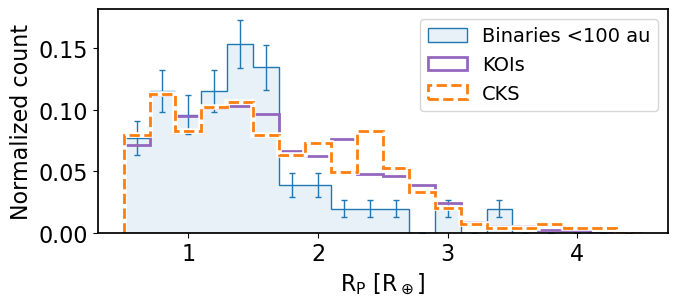

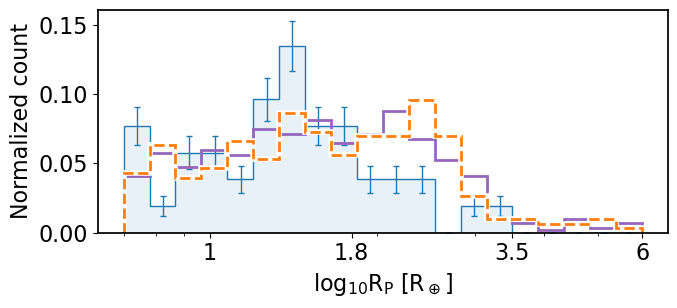

In [26]:

for option in ['linear','log']:

    nbins=20

    if option=='linear':
        histrange=[0.5,4.5]
        bin_edges = np.linspace(histrange[0], histrange[1], nbins + 1)
    else:
        histrange=[np.log10(0.7),np.log10(6)]
        bin_edges = np.logspace(histrange[0], histrange[1], nbins + 1)
        
    bin_width = np.diff(bin_edges)
    bin_center = bin_edges[:-1]+bin_width/2.
        
    fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

    close = binaries_filtered['SepAU']<100.
    nplanets = len(binaries_filtered[rad_good & close])
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    # planets with good radii in binary systems with rho<100 au and planet period < 100 days
    y, _, _ = plt.hist(binaries_filtered['Rppri'][rad_good & close], 
                  bins=bin_edges, weights=ww,
             histtype='stepfilled', edgecolor='#1f77b4', facecolor='#e8f1f7',
            label='Binaries <100 au')

    plt.errorbar(bin_center, y, np.sqrt(y)/len(y), ls='None', lw=1, capsize=2, c='C0')

    # compared to the kois that are at least not definite binaries with good radii and per<100 days
    nplanets = len(kois_filtered_cc[kois_cc_rad_good])
    plt.hist(kois_filtered_cc['koi_prad'][kois_cc_rad_good], 
                  bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step', lw=2, color='C4',
            label='KOIs')

    # compared to the cks
    nplanets = len(cks_filtered[cks_rad_good])
    plt.hist(cks_filtered['Rp'][cks_rad_good], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=4, color='white')
    plt.hist(cks_filtered['Rp'][cks_rad_good], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=2, linestyle='--', color='C1',
            label='CKS')

    plt.ylabel('Normalized count')
    
    if option=='linear':
        plt.legend()
        plt.xlabel('$R_P$ [$R_\oplus$]')        
    else:
        plt.xlabel('$log_{10} R_P$ [$R_\oplus$]')  
        plt.xscale('log')
        
        custom_log_ticks = [1, 1.8, 3.5, 6]
        plt.gca().set_xticks(custom_log_ticks)
        plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])
        
    plt.tight_layout()
    #plt.savefig('prad-'+option+'.png')

    plt.xlim()
    
    
    

In [91]:
bundle = {
    "binaries_filtered": binaries_filtered,      # pandas DataFrame
    "kois_filtered_cc": kois_filtered_cc,  # pandas DataFrame
    "binaries_unfiltered": binaries,  # pandas DataFrame
    "cks_filtered": cks_filtered,  # pandas DataFrame
}

with open(output_file, "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)


## Get numbers for paper

In [92]:
def calc_statistics(catalog, prad_col = 'Rp', star_col='KOI', MTPS=False):
    
    n_planets = float(len(catalog))
    print( "Number of planets: ", int(n_planets))
    print( "Number of stars: ", len(catalog[star_col].unique()))
    
    n_SEs = float(len(catalog.loc[catalog[prad_col]<parameters.radius_valley]))
    print("Frac super-Earths/n_planets: ", n_SEs/n_planets, "+-", np.sqrt(n_SEs)/n_planets)
    
    if MTPS:
        planet_counts = catalog.groupby(star_col).size().reset_index(name='n_planets')
        stps = len(planet_counts.loc[planet_counts['n_planets']==1])
        mtps = len(planet_counts.loc[planet_counts['n_planets']>1])
        print("Frac MTPS: ", mtps, stps, mtps/(stps+mtps), "+-", np.sqrt(mtps)/(stps+mtps))


# ----------------------------------------------
# Print all the samples and sub-samples
# ----------------------------------------------

        
print("BINARIES\n\n All")

print("\n Close BINARIES")
calc_statistics(binaries_filtered[close], prad_col='prad_adopt', MTPS=True)

print("\n Wide BINARIES")
calc_statistics(binaries_filtered[~close], prad_col='prad_adopt', MTPS=True)


print("\n\nSINGLE KOIS")
calc_statistics(kois_filtered_cc, prad_col='koi_prad', MTPS=True)

print("\nSINGLE CKS")
calc_statistics(cks_filtered, MTPS=True)



BINARIES

 All

 Close BINARIES
Number of planets:  113
Number of stars:  73
Frac super-Earths/n_planets:  0.672566371681416 +- 0.07714865386797654
Frac MTPS:  26 47 0.3561643835616438 +- 0.06984958237798335

 Wide BINARIES
Number of planets:  372
Number of stars:  269
Frac super-Earths/n_planets:  0.4731182795698925 +- 0.035662632154359136
Frac MTPS:  64 205 0.2379182156133829 +- 0.02973977695167286


SINGLE KOIS
Number of planets:  3150
Number of stars:  2343
Frac super-Earths/n_planets:  0.47555555555555556 +- 0.012286985701818175
Frac MTPS:  553 1790 0.23602219376867264 +- 0.010036684606320826

SINGLE CKS
Number of planets:  847
Number of stars:  584
Frac super-Earths/n_planets:  0.5171192443919717 +- 0.024708913266182228
Frac MTPS:  183 401 0.3133561643835616 +- 0.02316395420970665


### Investigate trends

/var/folders/4r/cvsgpy6j7b7gqxpbxpld3__80000gp/T/ipykernel_59077/941619466.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,300)


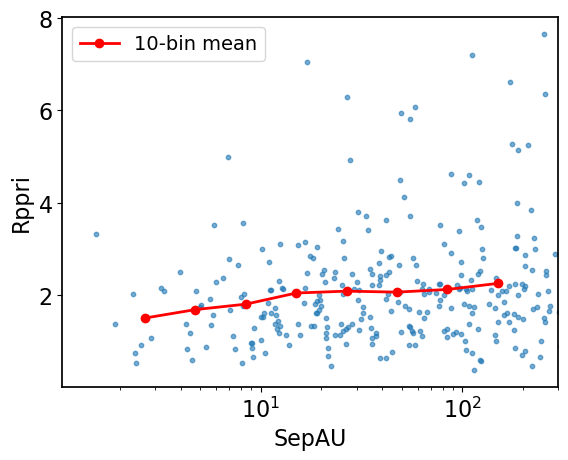

In [93]:
# biggest planet
max_rp = binaries_filtered.loc[binaries_filtered.groupby('KOI')['prad_adopt'].idxmax()].reset_index(drop=True)

# scatter 
y = max_rp['DiskAU']/max_rp['SnowAU']
plt.scatter(y, max_rp['prad_adopt'], s=10, alpha=0.6)
plt.xscale('log')
plt.xlabel('SepAU'); plt.ylabel('Rppri')
plt.xlim(0,300)

# 10 log-spaced bins (11 edges)
#bins = np.logspace(np.log10(20), np.log10(3000), 11)
bins = np.logspace(np.log10(2), np.log10(200), 9)

# assign points to bins
bin_idx = np.digitize(y.values, bins)

# keep only points inside [bins[0], bins[-1]]
valid = (bin_idx >= 1) & (bin_idx <= len(bins) - 1)
tmp = max_rp.loc[valid, ['Rppri']].copy()
tmp['bin'] = bin_idx[valid]

# mean Rppri per bin, ensure length 10 (fill missing bins with NaN)
means = tmp.groupby('bin')['Rppri'].mean().reindex(range(1, len(bins))).values

# plot at bin centers (geometric mean of edges)
centers = np.sqrt(bins[:-1] * bins[1:])
plt.plot(centers, means, color='red', linewidth=2, marker='o', label='10-bin mean')

plt.legend()
plt.show()

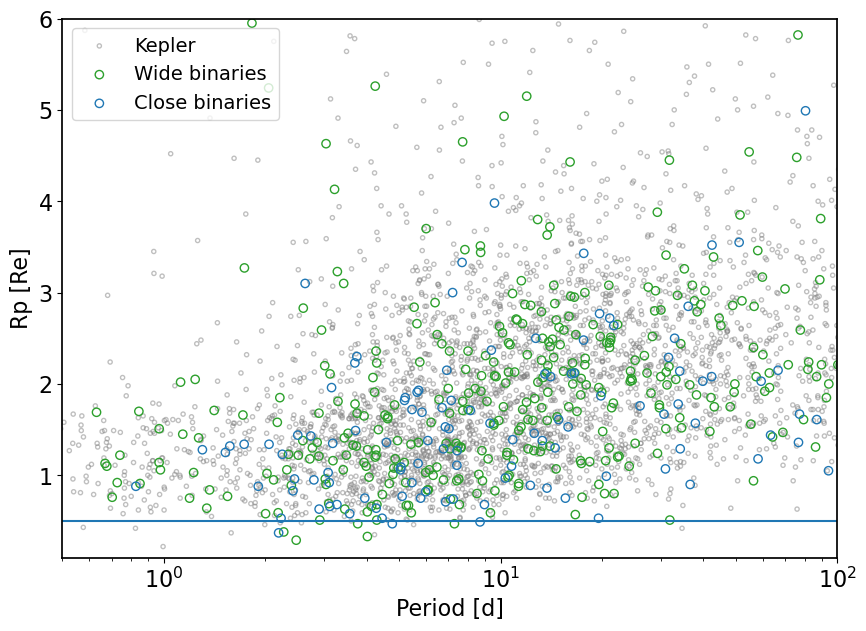

In [94]:
plt.figure(figsize=(10,7))
plt.scatter(kois_filtered_cc['koi_period'], kois_filtered_cc['koi_prad'], marker='.',
         edgecolor='gray', alpha=0.5, lw=1, facecolor='None', label='Kepler')

plt.scatter(binaries_filtered['koi_period'][~close], binaries_filtered['prad_adopt'][~close] ,
         edgecolor='C2', facecolor='None', lw=1, label='Wide binaries')
plt.scatter(binaries_filtered['koi_period'][close], binaries_filtered['prad_adopt'][close] ,
         edgecolor='C0', lw=1, facecolor='None', label='Close binaries')


plt.xlim(0.5,100)
plt.ylim(0.1,6)
plt.axhline(0.5)
plt.xscale('log')
plt.xlabel('Period [d]')
plt.ylabel('Rp [Re]')
plt.legend()